# Baseline Model — Mean-Pooled Embedding Classifier

**Task 2 — Yelp Polarity Sentiment Classification**

Clean, standalone baseline notebook (separate from the long exploratory `baseline.ipynb`).

## Architecture & embedding justification

- **Model:** trainable `nn.Embedding` + **masked mean pooling** + linear classifier.
- **Why this baseline:** simplest neural bag-of-embeddings model. It learns token
  vectors from scratch and averages them, so it ignores word order. That makes it
  a fair, weak-but-valid reference for comparing TextCNN (local n-grams) and
  BiLSTM (sequential context).
- **Embeddings:** randomly initialized and learned end-to-end. **No pretrained
  word vectors / language models** (assignment constraint).
- **Loss:** single logit + `BCEWithLogitsLoss`.

## Hardware used for the original reported run

- **GPU:** Tesla T4 (Colab) for the first full train; re-runs may show local GPU
- **Peak GPU memory:** ~98 MB
- **Training time:** ~233 s (5 epochs)
- **Parameters:** 3,840,129

## 0. Setup

In [1]:
import os
from pathlib import Path
import re
import json
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
)
from tqdm.auto import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Member folder = parent of src/ when cwd is src; otherwise cwd itself.
_cwd = Path.cwd().resolve()
BASE_DIR = str(_cwd.parent if _cwd.name == 'src' else _cwd)
os.makedirs(f"{BASE_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{BASE_DIR}/logs", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("BASE_DIR:", BASE_DIR)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

BASE_DIR: .
Device: cuda
GPU: NVIDIA GeForce RTX 4090


## 1. Load data + quick EDA (class balance, review length, missing values)

In [2]:
dataset = load_dataset("fancyzhx/yelp_polarity")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

train_df["label"] = train_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

print("Raw shapes:", train_df.shape, test_df.shape)
print("\nMissing values (train):")
print(train_df.isna().sum())
print("\nMissing values (test):")
print(test_df.isna().sum())

# Handle missing / empty reviews if any
n_train_before, n_test_before = len(train_df), len(test_df)
train_df = train_df.dropna(subset=["text", "label"]).copy()
test_df = test_df.dropna(subset=["text", "label"]).copy()
train_df = train_df[train_df["text"].astype(str).str.strip().ne("")].reset_index(drop=True)
test_df = test_df[test_df["text"].astype(str).str.strip().ne("")].reset_index(drop=True)
print(f"\nDropped train={n_train_before - len(train_df)}, test={n_test_before - len(test_df)}")

print("\nTrain class distribution:")
print(train_df["label"].value_counts().sort_index())
print("\nTest class distribution:")
print(test_df["label"].value_counts().sort_index())

Raw shapes: (560000, 2) (38000, 2)

Missing values (train):
text     0
label    0
dtype: int64

Missing values (test):
text     0
label    0
dtype: int64

Dropped train=0, test=0

Train class distribution:
label
0    280000
1    280000
Name: count, dtype: int64

Test class distribution:
label
0    19000
1    19000
Name: count, dtype: int64


Review length (words) — train
count    560000.000000
mean        133.028873
std         122.611613
min           1.000000
25%          51.000000
50%          97.000000
75%         174.000000
max        1052.000000
Name: word_len, dtype: float64


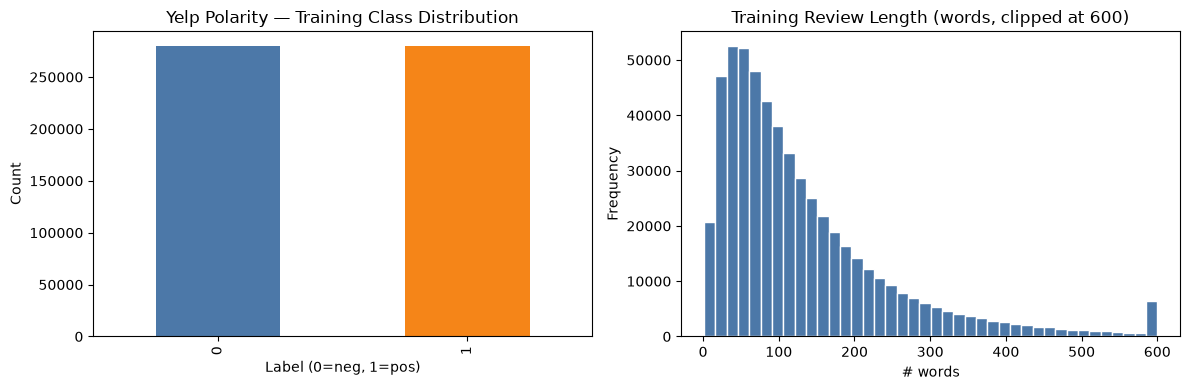

In [3]:
train_df["char_len"] = train_df["text"].astype(str).str.len()
train_df["word_len"] = train_df["text"].astype(str).str.split().str.len()

print("Review length (words) — train")
print(train_df["word_len"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df["label"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"]
)
axes[0].set_title("Yelp Polarity — Training Class Distribution")
axes[0].set_xlabel("Label (0=neg, 1=pos)")
axes[0].set_ylabel("Count")

axes[1].hist(train_df["word_len"].clip(upper=600), bins=40, color="#4C78A8", edgecolor="white")
axes[1].set_title("Training Review Length (words, clipped at 600)")
axes[1].set_xlabel("# words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 2. Text preprocessing + tokenization

Lowercasing, negation normalization, URL/HTML cleanup, punctuation removal,
stopword removal (keeping `no/not/nor/never`), and lemmatization.

In [4]:
stop_words = set(stopwords.words("english"))
negation_words = {"no", "not", "nor", "never"}
stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = text.lower()
    text = text.replace("\\n", " ").replace("\\r", " ")
    text = text.replace("\n", " ").replace("\r", " ")

    text = re.sub(r"\bwon't\b", "will not", text)
    text = re.sub(r"\bcan't\b", "can not", text)
    text = re.sub(r"n't\b", " not", text)

    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words
    ]
    return tokens


print(preprocess_text("The service wasn't good."))
print(preprocess_text("I can't recommend this place."))

['service', 'not', 'good']
['not', 'recommend', 'place']


In [5]:
train_split, val_split = train_test_split(
    train_df,
    test_size=0.10,
    random_state=42,
    stratify=train_df["label"],
)
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)
test_split = test_df.reset_index(drop=True)

for split_name, split_df in [
    ("train", train_split),
    ("val", val_split),
    ("test", test_split),
]:
    split_df["tokens"] = [
        preprocess_text(t) for t in tqdm(split_df["text"], desc=f"Preprocess {split_name}")
    ]

print("Sizes:", len(train_split), len(val_split), len(test_split))
print("Train labels:\n", train_split["label"].value_counts().sort_index())
print("Val labels:\n", val_split["label"].value_counts().sort_index())
print("Test labels:\n", test_split["label"].value_counts().sort_index())

Preprocess train:   0%|          | 0/504000 [00:00<?, ?it/s]

Preprocess val:   0%|          | 0/56000 [00:00<?, ?it/s]

Preprocess test:   0%|          | 0/38000 [00:00<?, ?it/s]

Sizes: 504000 56000 38000
Train labels:
 label
0    252000
1    252000
Name: count, dtype: int64
Val labels:
 label
0    28000
1    28000
Name: count, dtype: int64
Test labels:
 label
0    19000
1    19000
Name: count, dtype: int64


## 3. Vocabulary + embeddings learned from scratch

Vocab built from **training split only**. `MAX_LEN=160` (~90th percentile of
processed training lengths).

In [6]:
VOCAB_SIZE = 30000
MAX_LEN = 160
PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
PAD_IDX, UNK_IDX = 0, 1

word_counts = Counter()
for tokens in tqdm(train_split["tokens"], desc="Building vocabulary"):
    word_counts.update(tokens)

word_to_idx = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
for word, _ in word_counts.most_common(VOCAB_SIZE - 2):
    word_to_idx[word] = len(word_to_idx)

processed_lens = train_split["tokens"].apply(len)
print("Vocab size:", len(word_to_idx))
print("Processed length p50/p90/p95:",
      processed_lens.quantile(0.50),
      processed_lens.quantile(0.90),
      processed_lens.quantile(0.95))
print("Selected MAX_LEN:", MAX_LEN)

Building vocabulary:   0%|          | 0/504000 [00:00<?, ?it/s]

Vocab size: 30000
Processed length p50/p90/p95: 50.0 144.0 189.0
Selected MAX_LEN: 160


In [7]:
class YelpDataset(Dataset):
    def __init__(self, dataframe, word_to_idx, max_len):
        self.tokens = dataframe["tokens"].tolist()
        self.labels = dataframe["label"].tolist()
        self.word_to_idx = word_to_idx
        self.max_len = max_len
        self.pad_idx = word_to_idx["<PAD>"]
        self.unk_idx = word_to_idx["<UNK>"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        token_ids = [
            self.word_to_idx.get(token, self.unk_idx)
            for token in self.tokens[idx]
        ]
        if len(token_ids) == 0:
            token_ids = [self.unk_idx]

        token_ids = token_ids[: self.max_len]
        if len(token_ids) < self.max_len:
            token_ids += [self.pad_idx] * (self.max_len - len(token_ids))

        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float32),
        )


BATCH_SIZE = 128
train_dataset = YelpDataset(train_split, word_to_idx, MAX_LEN)
val_dataset = YelpDataset(val_split, word_to_idx, MAX_LEN)
test_dataset = YelpDataset(test_split, word_to_idx, MAX_LEN)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print(len(train_dataset), len(val_dataset), len(test_dataset))

504000 56000 38000


## 4. Baseline model

In [8]:
class MeanPoolBaseline(nn.Module):
    """Masked mean-pooled embedding classifier (Baseline)."""

    def __init__(self, vocab_size, embedding_dim, padding_idx, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=padding_idx
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embedding_dim, 1)

    def forward(self, input_ids):
        embeddings = self.embedding(input_ids)
        mask = (input_ids != self.embedding.padding_idx).unsqueeze(-1)
        summed = (embeddings * mask).sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = self.dropout(summed / lengths)
        return self.classifier(pooled).squeeze(1)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


EMBEDDING_DIM = 128
DROPOUT = 0.30
LEARNING_RATE = 1e-3
EPOCHS = 5

model = MeanPoolBaseline(
    vocab_size=len(word_to_idx),
    embedding_dim=EMBEDDING_DIM,
    padding_idx=PAD_IDX,
    dropout=DROPOUT,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print("Trainable parameters:", f"{count_parameters(model):,}")

MeanPoolBaseline(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 3,840,129


## 5. Train / evaluate helpers

In [9]:
def evaluate_basic(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_labels, all_predictions = [], []

    with torch.no_grad():
        for input_ids, labels in loader:
            input_ids = input_ids.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(input_ids)
            loss = criterion(logits, labels)
            total_loss += loss.item() * input_ids.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro")
    return avg_loss, acc, macro_f1


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    checkpoint_path,
    log_path,
):
    best_val_f1 = -1.0
    history = []

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    total_start = time.time()
    with open(log_path, "w", encoding="utf-8") as log_file:
        for epoch in range(1, epochs + 1):
            epoch_start = time.time()
            model.train()
            running_loss = 0.0
            examples_seen = 0

            for input_ids, labels in train_loader:
                input_ids = input_ids.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                optimizer.zero_grad()
                logits = model(input_ids)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()

                bs = input_ids.size(0)
                running_loss += loss.item() * bs
                examples_seen += bs

            train_loss = running_loss / examples_seen
            val_loss, val_acc, val_f1 = evaluate_basic(
                model, val_loader, criterion, device
            )
            epoch_time = time.time() - epoch_start
            examples_per_sec = examples_seen / epoch_time

            row = {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "val_macro_f1": val_f1,
                "epoch_time_sec": epoch_time,
                "examples_per_sec": examples_per_sec,
            }
            history.append(row)

            line = (
                f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f} | "
                f"Val Macro-F1: {val_f1:.4f} | Time: {epoch_time:.2f}s | "
                f"Examples/sec: {examples_per_sec:.2f}"
            )
            print(line)
            log_file.write(line + "\n")
            log_file.flush()

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "epoch": epoch,
                        "val_macro_f1": val_f1,
                        "max_len": MAX_LEN,
                        "vocab_size": len(word_to_idx),
                        "embedding_dim": EMBEDDING_DIM,
                        "dropout": DROPOUT,
                    },
                    checkpoint_path,
                )
                print(f"Best checkpoint saved (Macro-F1={val_f1:.4f})")

    total_time = time.time() - total_start
    peak_mem = (
        torch.cuda.max_memory_allocated() / (1024 ** 2)
        if torch.cuda.is_available()
        else 0.0
    )
    return history, total_time, peak_mem

## 6. Train baseline

Set `RETRAIN = False` only if `checkpoints/baseline_best.pt` already exists.
If this is your first clean-baseline run, leave `RETRAIN = True`.

In [10]:
RETRAIN = True  # set False after you have checkpoints/baseline_best.pt

checkpoint_path = f"{BASE_DIR}/checkpoints/baseline_best.pt"
log_path = f"{BASE_DIR}/logs/baseline_raw_training.log"

if RETRAIN or not os.path.exists(checkpoint_path):
    history, training_time, peak_memory = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        checkpoint_path=checkpoint_path,
        log_path=log_path,
    )
    pd.DataFrame(history).to_csv(
        f"{BASE_DIR}/outputs/baseline_training_history.csv", index=False
    )
else:
    print("Loading existing checkpoint:", checkpoint_path)
    summary_path = f"{BASE_DIR}/outputs/baseline_training_summary.json"
    if os.path.exists(summary_path):
        with open(summary_path, encoding="utf-8") as f:
            prev = json.load(f)
        training_time = prev.get("training_time_sec", float("nan"))
        peak_memory = prev.get("peak_gpu_memory_mb", float("nan"))
        history = []
    else:
        training_time, peak_memory, history = float("nan"), float("nan"), []

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("Loaded epoch:", checkpoint.get("epoch"))
print("Best val Macro-F1:", checkpoint.get("val_macro_f1"))
print(f"Training time: {training_time:.2f}s | Peak GPU mem: {peak_memory:.2f} MB")

Epoch 1/5 | Train Loss: 0.2662 | Val Loss: 0.1970 | Val Accuracy: 0.9264 | Val Macro-F1: 0.9264 | Time: 19.38s | Examples/sec: 26005.06
Best checkpoint saved (Macro-F1=0.9264)
Epoch 2/5 | Train Loss: 0.1957 | Val Loss: 0.1888 | Val Accuracy: 0.9301 | Val Macro-F1: 0.9301 | Time: 23.66s | Examples/sec: 21298.65
Best checkpoint saved (Macro-F1=0.9301)
Epoch 3/5 | Train Loss: 0.1859 | Val Loss: 0.1861 | Val Accuracy: 0.9317 | Val Macro-F1: 0.9317 | Time: 20.52s | Examples/sec: 24563.71
Best checkpoint saved (Macro-F1=0.9317)
Epoch 4/5 | Train Loss: 0.1809 | Val Loss: 0.1854 | Val Accuracy: 0.9319 | Val Macro-F1: 0.9319 | Time: 20.68s | Examples/sec: 24375.83
Best checkpoint saved (Macro-F1=0.9319)
Epoch 5/5 | Train Loss: 0.1771 | Val Loss: 0.1854 | Val Accuracy: 0.9321 | Val Macro-F1: 0.9321 | Time: 27.45s | Examples/sec: 18361.89
Best checkpoint saved (Macro-F1=0.9321)
Loaded epoch: 5
Best val Macro-F1: 0.9321249963421953
Training time: 111.91s | Peak GPU mem: 97.96 MB


## 7. Full test metrics

In [11]:
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob > bin_boundaries[i]) & (y_prob <= bin_boundaries[i + 1])
        if mask.sum() == 0:
            continue
        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.mean()) * abs(acc - conf)
    return float(ece)


def bootstrap_confidence_intervals(y_true, y_pred, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    accs, f1s, mccs = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        yt, yp = y_true[idx], y_pred[idx]
        accs.append(accuracy_score(yt, yp))
        f1s.append(f1_score(yt, yp, average="macro"))
        mccs.append(matthews_corrcoef(yt, yp))

    def ci(vals):
        return [float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))]

    return {"accuracy": ci(accs), "macro_f1": ci(f1s), "mcc": ci(mccs)}


all_labels, all_probs, all_preds = [], [], []
model.eval()
with torch.no_grad():
    for input_ids, labels in test_loader:
        input_ids = input_ids.to(device, non_blocking=True)
        logits = model(input_ids)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

y_true = np.array(all_labels)
y_prob = np.array(all_probs)
y_pred = np.array(all_preds)

accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro")
precision_micro = precision_score(y_true, y_pred, average="micro")
precision_weighted = precision_score(y_true, y_pred, average="weighted")
recall_macro = recall_score(y_true, y_pred, average="macro")
recall_micro = recall_score(y_true, y_pred, average="micro")
recall_weighted = recall_score(y_true, y_pred, average="weighted")
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_micro = f1_score(y_true, y_pred, average="micro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")
cm = confusion_matrix(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)
brier = brier_score_loss(y_true, y_prob)
ece = expected_calibration_error(y_true, y_prob)

print("=" * 50)
print("BASELINE TEST RESULTS")
print("=" * 50)
print(f"Accuracy:             {accuracy:.4f}")
print(f"Precision Macro:      {precision_macro:.4f}")
print(f"Precision Micro:      {precision_micro:.4f}")
print(f"Precision Weighted:   {precision_weighted:.4f}")
print(f"Recall Macro:         {recall_macro:.4f}")
print(f"Recall Micro:         {recall_micro:.4f}")
print(f"Recall Weighted:      {recall_weighted:.4f}")
print(f"F1 Macro:             {f1_macro:.4f}")
print(f"F1 Micro:             {f1_micro:.4f}")
print(f"F1 Weighted:          {f1_weighted:.4f}")
print(f"ROC-AUC:              {roc_auc:.4f}")
print(f"PR-AUC:               {pr_auc:.4f}")
print(f"MCC:                   {mcc:.4f}")
print(f"Brier Score:           {brier:.4f}")
print(f"ECE:                   {ece:.4f}")
print("Confusion Matrix:\n", cm)

BASELINE TEST RESULTS
Accuracy:             0.9342
Precision Macro:      0.9342
Precision Micro:      0.9342
Precision Weighted:   0.9342
Recall Macro:         0.9342
Recall Micro:         0.9342
Recall Weighted:      0.9342
F1 Macro:             0.9342
F1 Micro:             0.9342
F1 Weighted:          0.9342
ROC-AUC:              0.9805
PR-AUC:               0.9800
MCC:                   0.8684
Brier Score:           0.0499
ECE:                   0.0067
Confusion Matrix:
 [[17738  1262]
 [ 1239 17761]]


In [12]:
bootstrap_ci = bootstrap_confidence_intervals(y_true, y_pred)
print("95% Bootstrap CIs")
print("Accuracy:", bootstrap_ci["accuracy"])
print("Macro-F1:", bootstrap_ci["macro_f1"])
print("MCC:", bootstrap_ci["mcc"])

95% Bootstrap CIs
Accuracy: [0.9317625, 0.9366315789473684]
Macro-F1: [0.9317562854149456, 0.9366286396232658]
MCC: [0.8635132583782551, 0.873257360722498]


In [13]:
slice_negation_words = {"no", "not", "nor", "never", "none", "nobody", "nothing"}
token_lengths = test_split["tokens"].apply(len).to_numpy()
has_negation = test_split["tokens"].apply(
    lambda toks: any(t in slice_negation_words for t in toks)
).to_numpy()

slice_masks = {
    "Short (<=50 tokens)": token_lengths <= 50,
    "Medium (51-144 tokens)": (token_lengths > 50) & (token_lengths <= 144),
    "Long (>144 tokens)": token_lengths > 144,
    "Contains Negation": has_negation,
    "No Explicit Negation": ~has_negation,
}


def evaluate_slices(y_true, y_pred, slice_masks):
    rows = []
    for name, mask in slice_masks.items():
        yt, yp = y_true[mask], y_pred[mask]
        rows.append(
            {
                "slice": name,
                "n_examples": int(mask.sum()),
                "macro_f1": f1_score(yt, yp, average="macro") if len(yt) else float("nan"),
                "error_rate": float((yt != yp).mean()) if len(yt) else float("nan"),
            }
        )
    return pd.DataFrame(rows)


slice_results = evaluate_slices(y_true, y_pred, slice_masks)
print("BASELINE ROBUSTNESS BY DATA SLICE")
print(slice_results.to_string(index=False))

BASELINE ROBUSTNESS BY DATA SLICE
                 slice  n_examples  macro_f1  error_rate
   Short (<=50 tokens)       19274  0.936147    0.062831
Medium (51-144 tokens)       15046  0.933931    0.065532
    Long (>144 tokens)        3680  0.909917    0.082609
     Contains Negation       28293  0.926860    0.070689
  No Explicit Negation        9707  0.927593    0.051612


## 8. Save artifacts

This writes `baseline_predictions.csv`, which the BiLSTM notebook needs for McNemar tests.

In [14]:
param_count = count_parameters(model)
avg_eps = (
    float(np.mean([h["examples_per_sec"] for h in history]))
    if history
    else float("nan")
)
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

metrics = {
    "model": "baseline_meanpool",
    "accuracy": float(accuracy),
    "precision_macro": float(precision_macro),
    "precision_micro": float(precision_micro),
    "precision_weighted": float(precision_weighted),
    "recall_macro": float(recall_macro),
    "recall_micro": float(recall_micro),
    "recall_weighted": float(recall_weighted),
    "f1_macro": float(f1_macro),
    "f1_micro": float(f1_micro),
    "f1_weighted": float(f1_weighted),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "mcc": float(mcc),
    "brier_score": float(brier),
    "ece": float(ece),
    "confusion_matrix": cm.tolist(),
    "parameter_count": int(param_count),
    "training_time_sec": float(training_time) if training_time == training_time else None,
    "peak_gpu_memory_mb": float(peak_memory) if peak_memory == peak_memory else None,
    "gpu": gpu_name,
}

summary = {
    "model": "baseline_meanpool",
    "parameter_count": int(param_count),
    "training_time_sec": float(training_time) if training_time == training_time else None,
    "average_examples_per_sec": avg_eps if avg_eps == avg_eps else None,
    "peak_gpu_memory_mb": float(peak_memory) if peak_memory == peak_memory else None,
    "gpu": gpu_name,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "embedding_dim": EMBEDDING_DIM,
    "dropout": DROPOUT,
}

preds_df = pd.DataFrame(
    {
        "true_label": y_true.astype(int),
        "predicted_label": y_pred.astype(int),
        "positive_probability": y_prob.astype(float),
    }
)
preds_df.to_csv(f"{BASE_DIR}/outputs/baseline_predictions.csv", index=False)
pd.DataFrame(cm).to_csv(f"{BASE_DIR}/outputs/baseline_confusion_matrix.csv", index=False)
slice_results.to_csv(f"{BASE_DIR}/outputs/baseline_slice_results.csv", index=False)

with open(f"{BASE_DIR}/outputs/baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)
with open(f"{BASE_DIR}/outputs/baseline_training_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
with open(f"{BASE_DIR}/outputs/baseline_bootstrap_ci.json", "w", encoding="utf-8") as f:
    json.dump(bootstrap_ci, f, indent=2)

print("Saved baseline outputs to", f"{BASE_DIR}/outputs")
print("Key file for McNemar:", f"{BASE_DIR}/outputs/baseline_predictions.csv")

Saved baseline outputs to ./outputs
Key file for McNemar: ./outputs/baseline_predictions.csv


## Previous reported baseline numbers (from original explorative run)

| Metric | Value |
|---|---|
| Accuracy | 0.9338 |
| F1 macro/micro/weighted | 0.9338 |
| ROC-AUC | 0.9806 |
| PR-AUC | 0.9801 |
| MCC | 0.8676 |
| Brier | 0.0499 |
| ECE | 0.0070 |
| Acc 95% CI | [0.9315, 0.9363] |
| Params | 3,840,129 |
| Train time | 233.01 s |
| Peak GPU mem | 97.99 MB |
| GPU | Tesla T4 |

After you run this clean notebook, use the newly saved `baseline_*.json/csv` files
as the source of truth for submission (numbers may differ slightly by GPU/seed).